```
数据来源：鲸和社区https://www.heywhale.com/mw/dataset/668787e9727873e8e7da6bb0
数据文档
背景描述
自1955年在美国创立以来，麦当劳已发展成为全球快餐业的标志性品牌，其黄金拱门标志几乎遍布世界各地。随着市场环境的变化和技术的发展，麦当劳不断调整其市场营销策略，以适应不同地区消费者的需求和全球健康饮食趋势的变迁。近年来，数字化转型成为麦当劳战略的核心，包括线上点餐的使用、数字化营销的加大投入、以及顾客体验的优化，这一切都旨在提升品牌竞争力并深化与顾客的情感联系。
本数据集提供了针对麦当劳消费用户的市场调研信息，可以用于深入了解顾客偏好、评估产品与服务质量、优化价格策略、精确定位营销活动以及响应健康饮食趋势，从而帮助麦当劳制定更加精准的市场策略，提升顾客满意度和品牌竞争力。
数据说明
字段	说明
yummy	表示顾客是否觉得麦当劳的食物美味
convenient	表示顾客是否觉得麦当劳方便
spicy	表示顾客是否觉得麦当劳的食物辣
fattening	表示顾客是否觉得麦当劳的食物使人发胖
greasy	表示顾客是否觉得麦当劳的食物油腻
fast	表示顾客是否觉得麦当劳的服务快速
cheap	表示顾客是否觉得麦当劳便宜
tasty	表示顾客是否觉得麦当劳的食物可口
expensive	表示顾客是否觉得麦当劳昂贵
healthy	表示顾客是否觉得麦当劳的食物健康
disgusting	表示顾客是否觉得麦当劳的食物令人厌恶
Like	对麦当劳的整体喜好评分
Age	受访者的年龄
VisitFrequency	受访者光顾麦当劳的频率
Gender	受访者的性别
数据来源
https://www.kaggle.com/datasets/pamalkrmondal/mcdonalds-market-segmentation-dataset
问题描述
    顾客口味偏好分析
    价格敏感度分析
    消费频率预测
    顾客画像分类
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import re

In [3]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
data = pd.read_csv('mcdonalds.csv')

### 数据概览

In [5]:
name_mapping = {
    "yummy": "食物美味",
    "convenient": "方便",
    "spicy": "食物辣",
    "fattening": "使人发胖",
    "greasy": "食物油腻",
    "fast": "服务快速",
    "cheap": "便宜",
    "tasty": "食物可口",
    "expensive": "昂贵",
    "healthy": "食物健康",
    "disgusting": "食物令人厌恶",
    "Like": "整体喜好评分",
    "Age": "年龄",
    "VisitFrequency": "光顾频率",
    "Gender": "性别"
}
df = data.rename(columns=name_mapping)

In [6]:
df.head()

,Index,食物美味,方便,食物辣,使人发胖,食物油腻,服务快速,便宜,食物可口,昂贵,食物健康,食物令人厌恶,整体喜好评分,年龄,光顾频率,性别
0,1,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,2,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,3,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,4,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,5,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Index   1453 non-null   int64 
 1   食物美味    1453 non-null   object
 2   方便      1453 non-null   object
 3   食物辣     1453 non-null   object
 4   使人发胖    1453 non-null   object
 5   食物油腻    1453 non-null   object
 6   服务快速    1453 non-null   object
 7   便宜      1453 non-null   object
 8   食物可口    1453 non-null   object
 9   昂贵      1453 non-null   object
 10  食物健康    1453 non-null   object
 11  食物令人厌恶  1453 non-null   object
 12  整体喜好评分  1453 non-null   object
 13  年龄      1453 non-null   int64 
 14  光顾频率    1453 non-null   object
 15  性别      1453 non-null   object
dtypes: int64(2), object(14)
memory usage: 181.8+ KB


In [8]:
df.describe()

,Index,年龄
count,1453.000000,1453.000000
mean,727.000000,44.604955
std,419.589283,14.221178
min,1.000000,18.000000
25%,364.000000,33.000000
50%,727.000000,45.000000
75%,1090.000000,57.000000
max,1453.000000,71.000000


In [9]:
print('重复值数量：')
df.duplicated().sum

重复值数量：


<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1448    False
1449    False
1450    False
1451    False
1452    False
Length: 1453, dtype: bool>

### 数据预处理

In [10]:
#将所有逻辑值转化为二元数值
df = df.replace({"Yes": 1, "No": 0})

In [11]:
#将所有分类值转化为二元数值
df = df.replace({"Female": 0, "Male": 1})

In [12]:
#将字符型转化为数值型
def clean_score(score_str):
    # 只提取正负号+数字
    cleaned = re.sub(r'[^-+\d]', '', str(score_str))
    # 转成整数
    try:
        return int(cleaned)
    except:
        return 0  # 转失败就返回0

df['整体喜好评分'] = df['整体喜好评分'].apply(clean_score)

In [13]:
# 查看光顾频率所有取值
unique_values = df['光顾频率'].unique()
print("所有取值：", unique_values)

所有取值： ['Every three months' 'Once a week' 'Once a month' 'Once a year'
 'More than once a week' 'Never']


In [14]:
# 将字符型转化为数值型
freq_numeric = {
    "Never": 0,
    "Once a year": 1,
    "Every three months": 2,
    "Once a month": 3,
    "Once a week": 4,
    "More than once a week": 5
}
df['光顾频率_数值'] = df['光顾频率'].map(freq_numeric)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Index    1453 non-null   int64 
 1   食物美味     1453 non-null   int64 
 2   方便       1453 non-null   int64 
 3   食物辣      1453 non-null   int64 
 4   使人发胖     1453 non-null   int64 
 5   食物油腻     1453 non-null   int64 
 6   服务快速     1453 non-null   int64 
 7   便宜       1453 non-null   int64 
 8   食物可口     1453 non-null   int64 
 9   昂贵       1453 non-null   int64 
 10  食物健康     1453 non-null   int64 
 11  食物令人厌恶   1453 non-null   int64 
 12  整体喜好评分   1453 non-null   int64 
 13  年龄       1453 non-null   int64 
 14  光顾频率     1453 non-null   object
 15  性别       1453 non-null   int64 
 16  光顾频率_数值  1453 non-null   int64 
dtypes: int64(16), object(1)
memory usage: 193.1+ KB


In [16]:
df.head()

,Index,食物美味,方便,食物辣,使人发胖,食物油腻,服务快速,便宜,食物可口,昂贵,食物健康,食物令人厌恶,整体喜好评分,年龄,光顾频率,性别,光顾频率_数值
0,1,0,1,0,1,0,1,1,0,1,0,0,-3,61,Every three months,0,2
1,2,1,1,0,1,1,1,1,1,1,0,0,2,51,Every three months,0,2
2,3,0,1,1,1,1,1,0,1,1,1,0,1,62,Every three months,0,2
3,4,1,1,0,1,1,1,1,1,0,0,1,4,69,Once a week,0,4
4,5,0,1,0,1,1,1,1,0,0,1,0,2,49,Once a month,1,3


### 数据可视化

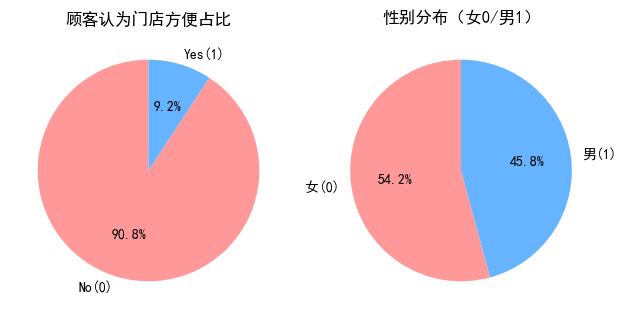

In [17]:
# 二元变量饼图（方便、性别）
binary_cols = ['方便', '性别']
titles = ['顾客认为门店方便占比',  '性别分布（女0/男1）']

fig, axes = plt.subplots(1, 2)
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts()
    if col == '性别':
        labels = ['女(0)', '男(1)']
    else:
        labels = ['No(0)', 'Yes(1)']
    colors = ['#ff9999','#66b3ff']
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    axes[i].set_title(titles[i], fontsize=12)

plt.tight_layout()
plt.show()

```
顾客普遍认为门店不方便，麦当劳应该进行多处选址扩大门店辐射范围，或提高服务质量
顾客男女分布差距不大，但女性偏多
```

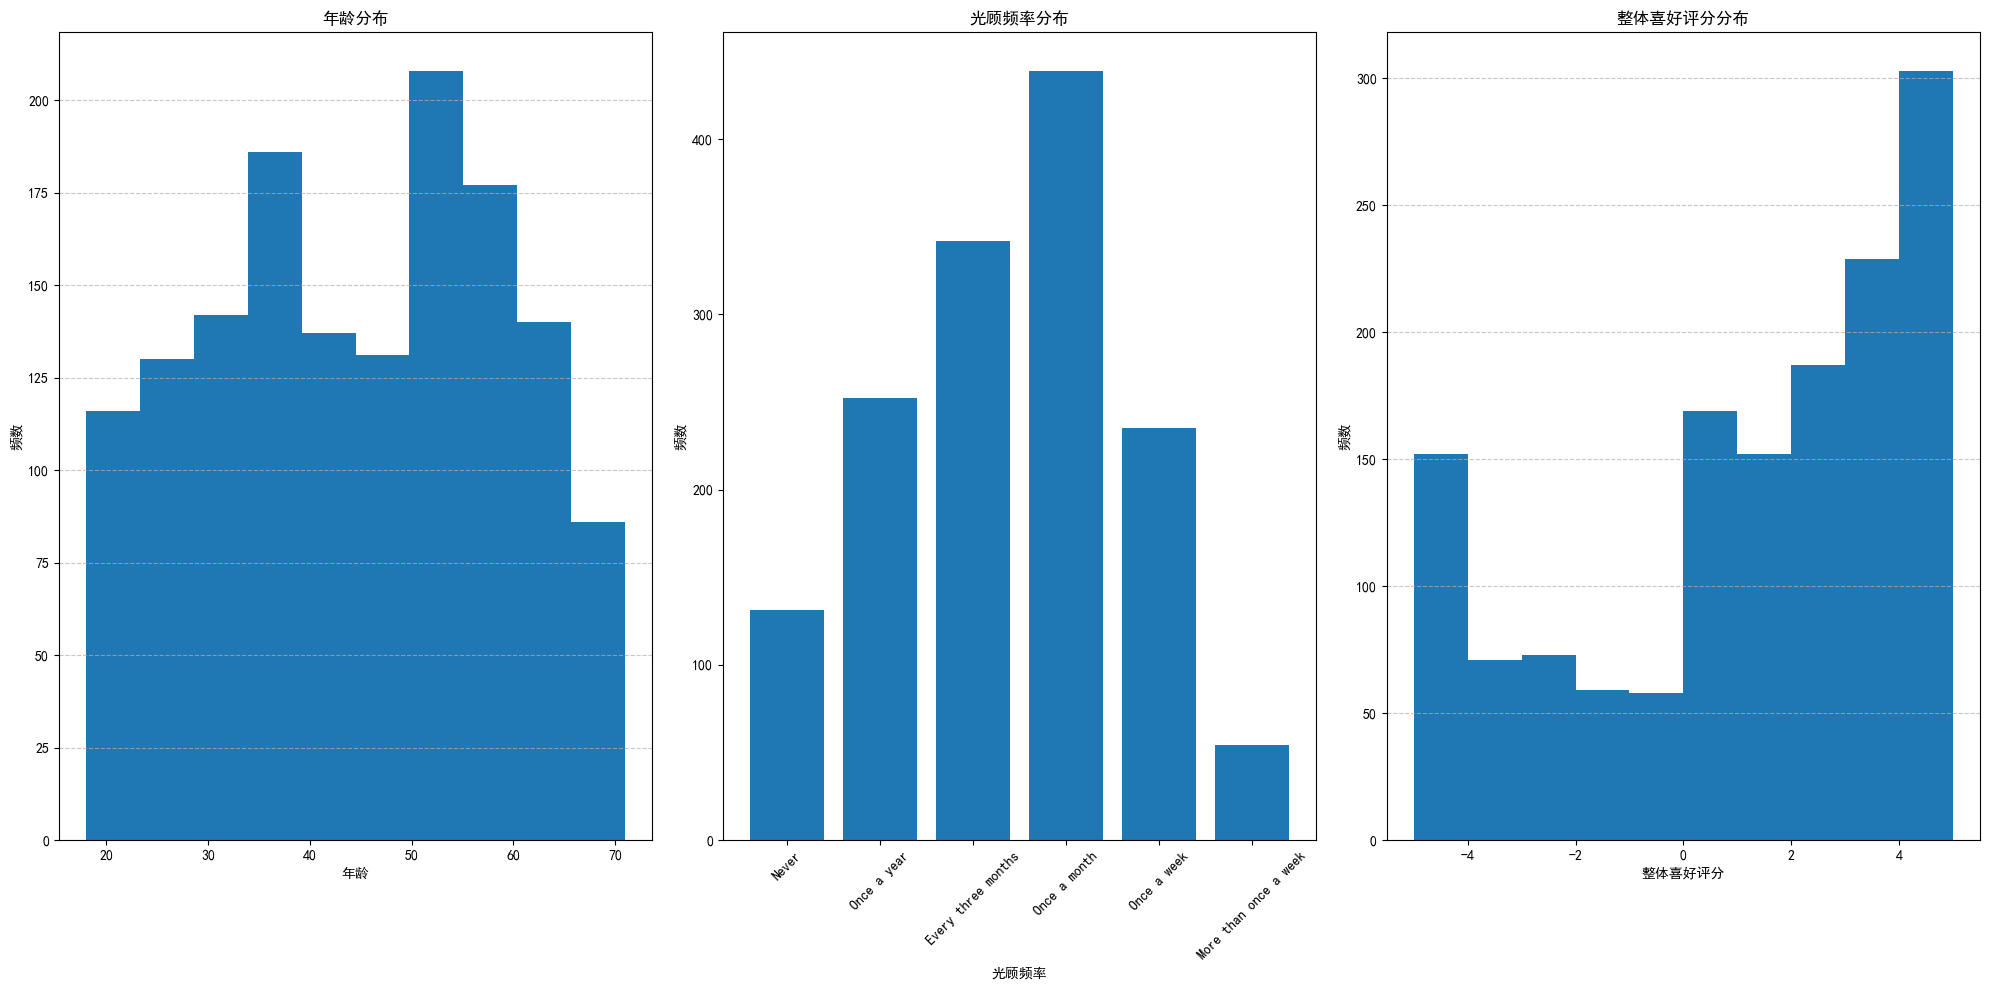

In [18]:
# 数值变量直方图
fig, axes = plt.subplots(1,3,figsize=(20,10))
# 1. 年龄分布直方图
axes[0].hist(df['年龄'], bins=10)
axes[0].set_title('年龄分布')
axes[0].set_xlabel('年龄')
axes[0].set_ylabel('频数')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
# 2. 光顾频率分布直方图
freq_order = ["Never", "Once a year", "Every three months", "Once a month", "Once a week", "More than once a week"]
freq_count = df['光顾频率'].value_counts().reindex(freq_order)  
axes[1].bar(freq_count.index, freq_count.values)
axes[1].set_title('光顾频率分布')
axes[1].set_xlabel('光顾频率')
axes[1].set_ylabel('频数')
axes[1].tick_params(axis='x', rotation=45)  
# 3. 整体喜好评分分布直方图
axes[2].hist(df['整体喜好评分'])
axes[2].set_title('整体喜好评分分布')
axes[2].set_xlabel('整体喜好评分')
axes[2].set_ylabel('频数')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

```
1. 年龄分布
样本年龄分布呈双峰特征：主要集中在30-40岁和50-60岁两个区间，说明麦当劳的顾客群体以中青年和中老年为主
整体覆盖 0-70岁，数据分布较广
2. 光顾频率分布
最主流的消费频率是Once a month（每月一次），其次是Every three months（每三个月一次），说明顾客以低频消费为主。
高频顾客（Once a week及以上）占比很低，反映出品牌对高频用户的吸引力仍有提升空间。
3. 整体喜好评分分布
整体呈明显右偏分布：高分（3-5分）的顾客数量远多于低分顾客，说明大部分用户对麦当劳的整体体验是满意的。
极端负面评价（-5、-4分）的数量也不少，反映出仍有部分顾客体验较差，是后续优化的重点。
```

### 顾客口味偏好分析

In [19]:
# 定义口味相关字段
taste_cols = ['食物美味','食物辣','食物油腻','使人发胖','食物健康','食物可口','食物令人厌恶']

In [20]:
#计算各口味指标的“评价占比”
taste_positive = {}
for col in taste_cols:
    positive_rate = (df[col] == 1).mean()*100
    taste_positive[col] = round(positive_rate, 2)      
#转化为DataFrame便于可视化
taste_df = pd.DataFrame(list(taste_positive.items()), columns=['口味指标', '评价占比(%)'])
print(taste_df)

     口味指标  评价占比(%)
0    食物美味    55.26
1     食物辣     9.36
2    食物油腻    52.65
3    使人发胖    86.72
4    食物健康    19.89
5    食物可口    64.42
6  食物令人厌恶    24.29


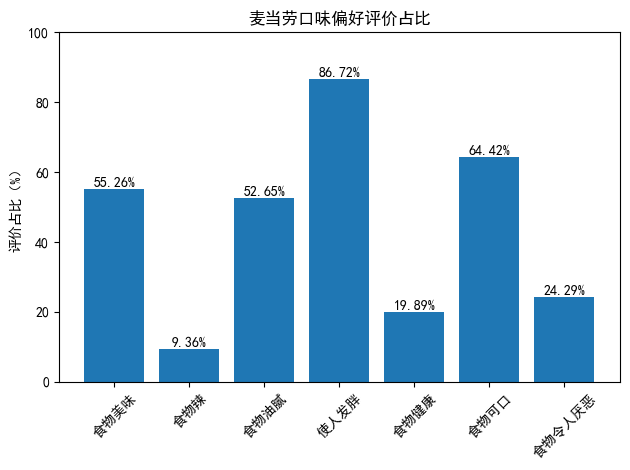

In [21]:
# 绘制口味偏好柱状图
fig, ax = plt.subplots()
bars = ax.bar(taste_df['口味指标'], taste_df['评价占比(%)'])

#添加数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,f'{height}%', ha='center', va='bottom')
ax.set_title('麦当劳口味偏好评价占比')
ax.set_ylabel('评价占比（%）')
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```
食物美味：超半数顾客认可口味，品牌口味比较受大众接受
食物辣：顾客普遍认为食物不辣，可以适当出一款产品增加辣度满足喜辣顾客的需要
食物油腻：超半数的顾客认为食物油腻，可加强品牌的控油力度
使人发胖：绝大多数的顾客认为食物使人发胖，品牌应该加强控油力度或推出清淡健康的减脂餐等改善顾客印象
食物健康：只有少数顾客认为食物健康，品牌可推出健康产品改善顾客印象
食物可口：超过六成的顾客认为食物可口，说明食物口味受大众欢迎
食物令人厌恶：有将近四分之一的负面口味反馈，品牌应进行相关的跟踪访问，推出符合相关用户口味的产品，减少负面评价
```

### 价格敏感度分析

In [22]:
# 定义价格相关字段
price_cols = ['便宜','昂贵']

In [23]:
# 计算价格敏感度分布
price_sensitivity = {}
# 价格敏感人群：认为“价格昂贵”或不认为“价格便宜”
df['价格敏感'] = ((df['昂贵'] == 1) | (df['便宜'] == 0)).astype(int)
price_sensitivity['价格敏感人群占比'] = round(df['价格敏感'].mean() * 100, 2)
price_sensitivity['非价格敏感人群占比'] = round((1 - df['价格敏感']).mean() * 100, 2)

In [24]:
# 价格敏感度与光顾频率的关联
price_freq = df.groupby('价格敏感')['光顾频率_数值'].mean().round(2)
price_sensitivity['敏感人群平均光顾频率'] = price_freq[1]
price_sensitivity['非敏感人群平均光顾频率'] = price_freq[0]

In [25]:
# 输出结果
print("\n顾客价格敏感度分析：")
for k, v in price_sensitivity.items():
    print(f"{k}: {v}")


顾客价格敏感度分析：
价格敏感人群占比: 44.6
非价格敏感人群占比: 55.4
敏感人群平均光顾频率: 2.27
非敏感人群平均光顾频率: 2.47


```
1.整体价格敏感度不高
超过一半的顾客对价格不敏感，说明品牌的定价在目标客群中接受度较好，价格不是阻碍消费的核心因素。
2.价格敏感度与光顾频率呈弱负相关
非价格敏感人群的平均光顾频率（2.47）略高于敏感人群（2.27），说明价格敏感的顾客消费频次更低，但差距不大，说明价格并非影响复购的唯一关键因素。
3.潜在运营机会
占比44.6%的价格敏感人群，是提升复购的关键抓手。他们对价格更敏感，推出针对性优惠更易刺激消费频次提升。
```

### 消费频率预测

#### 构建预测模型

In [26]:
# 定义特征变量 X 和目标变量 Y
X = pd.DataFrame()
# 顾客感知特征
X['食物美味'] = df['食物美味']
X['方便'] = df['方便']
X['食物辣'] = df['食物辣']
X['使人发胖'] = df['使人发胖']
X['食物油腻'] = df['食物油腻']
X['服务快速'] = df['服务快速']
X['便宜'] = df['便宜']
X['食物可口'] = df['食物可口']
X['昂贵'] = df['昂贵']
X['食物健康'] = df['食物健康']
X['食物令人厌恶'] = df['食物令人厌恶']
# 整体评分
X['整体喜好评分'] = df['整体喜好评分']
# 人口统计特征
X['年龄'] = df['年龄']
X['性别'] = df['性别']  # 0=女,1=男
# 目标：光顾频率数值
y = df['光顾频率_数值']

In [27]:
# 划分训练集和测试集
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 0)

#### 线性模型构建

In [28]:
# 训练线性回归模型
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
# 模型评估
y_pred = model.predict(X_test)
r2 = round(r2_score(y_test,y_pred),4)

In [30]:
# 分析特征重要性
feature_importance = pd.DataFrame({
    '特征': X.columns,
    '回归系数': model.coef_.round(4)
}).sort_values(by='回归系数', ascending=False) 
print(f"线性模型R²得分：{r2}")
print("\n特征对消费频率的影响（回归系数）：")
print(feature_importance)

线性模型R²得分：0.5254

特征对消费频率的影响（回归系数）：
        特征    回归系数
1       方便  0.3851
8       昂贵  0.2757
11  整体喜好评分  0.2370
6       便宜  0.1861
0     食物美味  0.1791
13      性别  0.1540
2      食物辣  0.0875
12      年龄 -0.0113
7     食物可口 -0.0381
4     食物油腻 -0.0957
9     食物健康 -0.1057
3     使人发胖 -0.1185
10  食物令人厌恶 -0.1844
5     服务快速 -0.2207


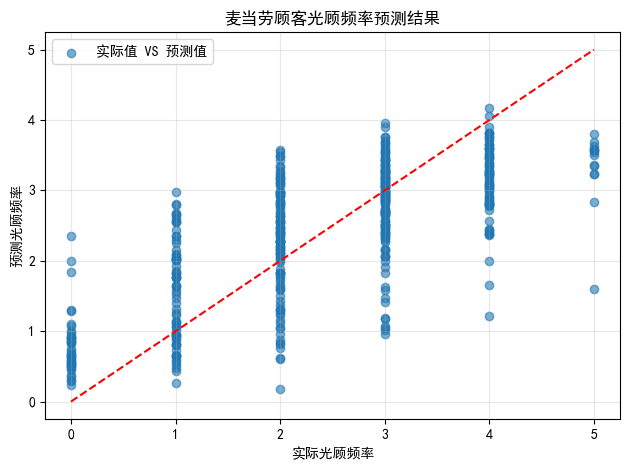

In [31]:
fig,ax = plt.subplots()
ax.scatter(y_test, y_pred,alpha=0.6,label = '实际值 VS 预测值')
# 添加对角线（完美预测线）
ax.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='r',linestyle='--')

ax.set_xlabel('实际光顾频率')
ax.set_ylabel('预测光顾频率')
ax.set_title(f'麦当劳顾客光顾频率预测结果')
ax.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

```
散点整体沿完美预测线分布，趋势一致性良好，
对中间频率（1-4 级）顾客的预测精度较高；
仅在极端低频率（0 级）和高频率（5 级）样本上仍存在少量偏差
```

#### 非线性模型构建（随机森林）

In [32]:
# 训练非线性模型
model = RandomForestRegressor(
    n_estimators=150,  
    max_depth=8,       
    random_state=0
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [33]:
# 模型预测与评分
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"非线性模型R²评分：{r2:.4f}")

feature_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': model.feature_importances_.round(4)
}).sort_values(by='重要性', ascending=False)

print("\n特征重要性：")
print(feature_importance)

非线性模型R²评分：0.5051

特征重要性：
        特征     重要性
11  整体喜好评分  0.6168
12      年龄  0.1695
13      性别  0.0292
8       昂贵  0.0222
10  食物令人厌恶  0.0218
1       方便  0.0185
2      食物辣  0.0184
4     食物油腻  0.0180
0     食物美味  0.0168
7     食物可口  0.0162
6       便宜  0.0155
5     服务快速  0.0138
9     食物健康  0.0135
3     使人发胖  0.0099


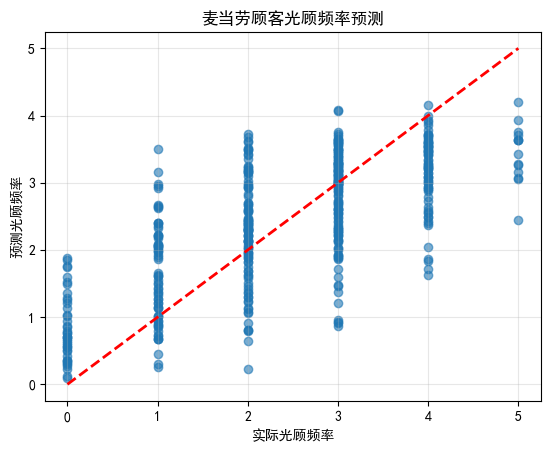

In [34]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('实际光顾频率')
plt.ylabel('预测光顾频率')
plt.title(f'麦当劳顾客光顾频率预测')
plt.grid(alpha=0.3)
plt.show()

```
散点整体沿完美预测线分布，趋势一致性良好
，对中间频率（2-4 级）顾客的预测精度较高；
极端低频率（0 级）和高频率（5 级）样本的偏差也得到有效改善
```

#### 模型对比总结

```
1.模型表现
线性模型 R²=0.5254，非线性模型 R²=0.5051
两者表现接近，线性模型略优，说明顾客光顾频率整体呈现近似线性关系。
2.关键影响因素
整体喜好评分是最核心驱动因素:
    非线性模型显示其重要性高达61.68%，线性模型也显著正向，
    说明提升整体满意度是提高顾客光顾频率最有效的手段。
便利性是重要推动因素:
    线性回归中“方便”系数最高，
    说明门店可及性、购买便捷性显著提升复购。
年龄具有重要分段影响:
    非线性模型显示年龄重要性达16.95%，中青年群体是高频消费主力。
负面体验显著抑制消费:
    食物令人厌恶、油腻、发胖感等均对光顾频率有负向作用。
3.管理建议
重点提升整体用餐体验，而非单一口味优化
强化便利性布局（选址、外送、自助点单）
针对中青年客群做精准营销
控制难吃、油腻等负面感知
```

### 用户画像分类

#### K-Means聚类

In [35]:
# 特征选择：结合两个模型选择重要性较大的特征
cluster_features = [
    '整体喜好评分', '方便', '年龄', '性别',
    '便宜', '昂贵', '食物美味', '食物可口',
    '使人发胖', '食物油腻', '食物令人厌恶', '服务快速'
]
X_cluster = df[cluster_features].copy()

In [36]:
# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

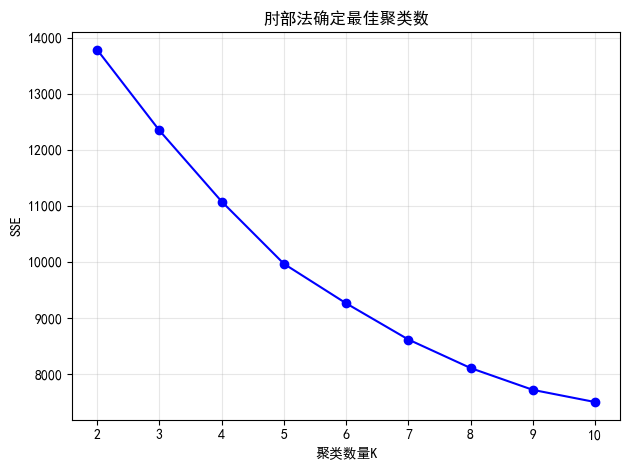

In [37]:
# 肘部法计算最佳K值
SSE= []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(
        n_clusters=k, 
        random_state=0,
        n_init=10,
        max_iter=300
    )
    kmeans.fit(X_scaled)
    SSE.append(kmeans.inertia_)

# 可视化肘部法效果
plt.figure()
plt.plot(k_range, SSE,'bo-')
plt.xlabel('聚类数量K')
plt.ylabel('SSE')
plt.title('肘部法确定最佳聚类数')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# 最佳K=5
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)
df['用户画像'] = kmeans.fit_predict(X_scaled)

In [39]:
# 输出每类画像
profile = df.groupby('用户画像')[cluster_features + ['光顾频率_数值']].mean().round(3)
profile['人数占比(%)'] = df['用户画像'].value_counts(normalize=True).sort_index() * 100

In [40]:
print("麦当劳顾客画像分类（K=5）")
print(profile.round(2))

麦当劳顾客画像分类（K=5）
      整体喜好评分    方便     年龄    性别    便宜    昂贵  食物美味  食物可口  使人发胖  食物油腻  食物令人厌恶  \
用户画像                                                                          
0       2.20  0.98  38.84  0.54  0.13  0.96  0.86  0.92  0.99  0.63    0.13   
1       2.50  0.99  41.25  0.37  0.91  0.00  0.85  0.97  1.00  0.46    0.05   
2      -1.96  1.00  49.35  0.45  0.58  0.35  0.02  0.12  0.98  0.67    0.50   
3      -3.89  0.00  49.53  0.55  0.34  0.63  0.02  0.07  0.88  0.75    0.83   
4       2.81  0.95  49.83  0.53  0.69  0.21  0.74  0.83  0.00  0.08    0.02   

      服务快速  光顾频率_数值  人数占比(%)  
用户画像                          
0     0.86     2.86    19.68  
1     0.97     2.89    33.93  
2     0.91     1.60    27.05  
3     0.62     0.86     7.71  
4     0.93     2.92    11.63  


#### 聚类结果可视化（PCA降维）

In [41]:
pca = PCA(n_components=2,random_state=0)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

In [42]:
# 聚类标签
cluster_labels = [
    '0 高满意度群体',
    '1 高性价比高频客',
    '2 中立低频次客',
    '3 低满意流失客',
    '4 高频高体验客'
]

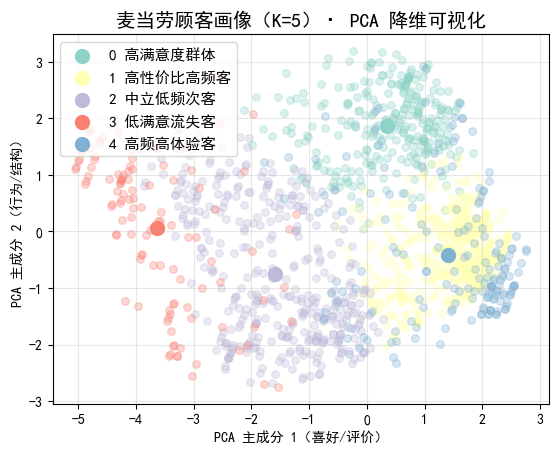

In [43]:
plt.figure()
colors = plt.cm.Set3.colors[:5] 
# 画所有样本点（看分布）
for i in range(5):
    mask = df['用户画像'] == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[i], alpha=0.3, s=30
    )

# 再画聚类中心（标注群体）
for i in range(5):
    plt.scatter(
        centers_pca[i, 0], centers_pca[i, 1],
        c=colors[i], s=100, label=cluster_labels[i]
    )
    

plt.title('麦当劳顾客画像（K=5）', fontsize=14)
plt.xlabel('PCA 主成分 1（喜好/评价）')
plt.ylabel('PCA 主成分 2（行为/结构）')
plt.legend(prop={'size':11})
plt.grid(alpha=0.3)
plt.show()

```
结果显示，5类顾客群体在PCA平面上呈现出良好的区分度，聚类效果稳定可靠。
其中，高满意度群体、高性价比高频客与高频高体验客集中分布于右侧，是品牌的核心客群；
低满意流失客则与其他群体明显分离，负面特征突出；
中立低频次客处于中间地带，具有较高的转化潜力。
```

### 总结

```
一、顾客基础特征与行为概览
人口结构
    性别分布均衡，女性占比 54.2%，男性占比 45.8%，覆盖广泛。
    年龄呈双峰分布，30-40岁中青年与50-60岁中老年是主要客群，整体覆盖0-70岁，用户基础多元。
    门店便利性认知分化明显：仅9.2%的顾客认为门店“方便”，90.8%的顾客认为便利性不足，是影响消费体验的关键短板。
消费行为
    光顾频率以低频为主：“每月一次”“每三个月一次” 是主流，高频消费（每周一次及以上）占比低，品牌对高频用户的吸引力仍有提升空间。
    整体满意度呈右偏分布：高分顾客占比远高于低分顾客，多数用户对品牌体验认可，但仍有部分极端负面评价，体验优化存在明确空间。
二、口味偏好分析：口味认可度高，健康顾虑突出
优势项：超半数顾客认可 “食物美味”“食物可口”，品牌口味基础扎实，是用户留存的核心优势。
待优化项：
    顾客普遍反馈食物 “油腻”“易使人发胖”，仅少数人认为食物健康，健康顾虑是主要负面感知。
    近四分之一顾客存在 “食物令人厌恶” 的负面反馈，需针对性排查产品问题，减少负面评价。
    食物辣度接受度低，可推出辣味产品，满足细分客群需求。
三、价格敏感度分析：定价接受度良好，价格非核心制约
整体敏感度低：超过半数顾客对价格不敏感，品牌定价在目标客群中接受度较高，价格并非阻碍消费的核心因素。
价格与复购弱相关：价格敏感人群占比44.6%，其光顾频率（2.27）略低于非敏感人群（2.47），说明价格对复购的影响有限，但仍可通过针对性优惠刺激敏感人群消费频次提升。
四、消费频率预测：满意度与便利性是核心驱动
模型表现：线性回归模型（R²=0.5254）与非线性随机森林模型（R²=0.5051）表现接近，线性模型略优，说明顾客光顾频率整体呈近似线性关系，所选特征可解释超过一半的消费频率差异。
关键影响因素：
    整体喜好评分：非线性模型中重要性达 61.68%，是驱动复购的最核心因素，提升整体体验比单一口味优化更有效。
    便利性：线性回归中 “方便” 系数最高，门店可及性、购买便捷性显著影响复购意愿。
    负面体验抑制消费：食物油腻、发胖感、令人厌恶等负面感知，均对光顾频率有显著负向作用。
    年龄分段影响：中青年群体是高频消费主力，需针对性开展精准营销。
五、顾客画像分类：5 类群体特征清晰，分层运营空间大
基于 K-Means 聚类（K=5）与PCA降维可视化，顾客被划分为 5 类特征鲜明的群体，聚类区分度良好：
画像类型	            核心特征	               运营定位
高满意度群体	整体评价高、复购意愿强	        品牌核心忠实用户，需重点维护
高性价比高频客	重视性价比、消费频次高	        消费主力人群，可通过会员体系强化粘性
中立低频次客	评价中等、消费频次低	        可转化客群，需通过体验优化激活复购
低满意流失客	负面评价突出、几乎不再光顾	   流失风险用户，需针对性改善体验
高频高体验客	重视品质、高频消费	           价值导向型客群，可通过高端产品提升留存
六、核心结论与管理建议
    优先提升整体体验，强化便利性短板
    以提升顾客整体满意度为核心，同步优化门店选址、外送服务、自助点单等便利性环节，破解 “便利性认知不足” 的核心痛点。
    针对性改善健康感知，优化产品结构
    推出清淡、减脂类健康产品，降低顾客对 “油腻、发胖” 的负面印象；排查并优化引发 “令人厌恶” 反馈的产品，减少负面评价。
    实施分层运营策略，激活不同客群
    对高满意度与高频客群，通过会员权益、专属产品强化粘性；
    对中立低频次客群，推出优惠券、限时活动刺激复购；
    对流失客群，通过调研定位体验痛点，开展挽回运营。
    聚焦中青年客群，提升高频消费吸引力
    针对30-40岁中青年主力客群，推出符合其需求的产品与营销活动，提升高频消费占比，改善以低频为主的消费结构。
```